# COMP 6940: Big Data and Data Visualization

### Project: Airline Delay Analysis and Performance Optimization  
#### Dataset: Carrier On-Time Performance Dataset  

## **Notebook:** 04 - Airport Clustering

**Objective:** 

This notebook applies **K-Means clustering** to group airports according to their **delay profiles and operational characteristics**. While the previous notebooks examined delay patterns by cause, airline, airport, route, and time period, this notebook shifts the focus toward **unsupervised learning**, with the goal of identifying airports that behave similarly in terms of delay structure.

To do this, airport-level features are first aggregated from the operational flight data, then standardized so that variables measured on different scales can be compared fairly. K-Means clustering is subsequently used to partition airports into groups with similar delay patterns, and the resulting clusters are evaluated using **elbow** and **silhouette** methods before being interpreted through centroid summaries and PCA-based visualization.

The purpose of this analysis is to uncover whether airports naturally separate into distinct operational types, such as those dominated by **congestion**, **delay propagation**, or relatively lower-disruption performance. This provides a higher-level structural view of the airport network and helps identify groups of airports that may require different operational strategies or policy interventions.

---

## Setup and Data Preparation

This section initializes the required libraries, defines key variables, and prepares the dataset for analysis.

- Core libraries such as **NumPy, Pandas, Matplotlib, and Seaborn** are imported for data handling and visualization.
- Machine learning tools from **scikit-learn** are used for clustering (K-Means), dimensionality reduction (PCA), and evaluation (silhouette score).
- Key delay-related variables and feature columns are defined to structure the analysis.
- The cleaned flight dataset is loaded, and relevant columns are converted into appropriate formats for further processing.

Only completed flights (i.e., non-cancelled flights) are retained to ensure that delay analysis reflects actual operational performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

CAUSES = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]
CAUSE_LABELS = ["Carrier", "Weather", "NAS", "Security", "Late aircraft"]

FEATURE_COLS = [
    "DelayedFlightRate",
    "AvgArrDelay",
    "AvgCarrierDelay",
    "AvgWeatherDelay",
    "AvgNASDelay",
    "AvgSecurityDelay",
    "AvgLateAircraftDelay",
    "CarrierShare",
    "WeatherShare",
    "NASShare",
    "SecurityShare",
    "LateAircraftShare",
]

In [2]:
df = pd.read_csv("cleaned_flight_data.csv", low_memory=False)
for c in CAUSES:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

if "IsArrivalDelayed" not in df.columns:
    df["IsArrivalDelayed"] = pd.to_numeric(df["ArrDelay"], errors="coerce").fillna(0) > 0
else:
    df["IsArrivalDelayed"] = df["IsArrivalDelayed"].astype(bool)

oper = df[df["Cancelled"] == 0].copy()
oper["ArrDelay"] = pd.to_numeric(oper["ArrDelay"], errors="coerce")

## Step 1: Aggregate Airport-Level Features

In this step, flight-level data is aggregated to construct **airport-level feature profiles**. Each airport is represented by a set of summary statistics that capture both the **frequency** and **severity** of delays.

The aggregation includes:
- **FlightsCount**: total number of completed flights originating from the airport  
- **DelayedFlightRate**: proportion of flights that arrive late  
- **AvgArrDelay**: average arrival delay per flight  
- **Average delay by cause** (Carrier, Weather, NAS, Security, Late Aircraft)  
- **Proportional shares of each delay cause**  

These features form the basis for clustering, allowing airports to be compared based on their overall delay behavior and the composition of delay causes.

The table below shows the resulting airport-level feature set. Each row corresponds to an airport, with columns representing delay-related metrics that will be used for clustering.

In [3]:
g = oper.groupby("Origin", observed=True)
sum_c = g[CAUSES].sum()
tot = sum_c.sum(axis=1).replace(0, np.nan)
shares = sum_c.div(tot, axis=0).fillna(0)
shares.columns = [
    "CarrierShare",
    "WeatherShare",
    "NASShare",
    "SecurityShare",
    "LateAircraftShare",
]

profiles = pd.DataFrame({
    "FlightsCount": g.size(),
    "DelayedFlightRate": g["IsArrivalDelayed"].mean(),
    "AvgArrDelay": g["ArrDelay"].mean(),
})
profiles = profiles.join(g[CAUSES].mean().rename(columns=lambda x: "Avg" + x))
profiles = profiles.join(shares)
profiles = profiles.reset_index()
profiles.head()

,Origin,FlightsCount,DelayedFlightRate,AvgArrDelay,AvgCarrierDelay,AvgWeatherDelay,AvgNASDelay,AvgSecurityDelay,AvgLateAircraftDelay,CarrierShare,WeatherShare,NASShare,SecurityShare,LateAircraftShare
0,ABE,1596,0.402256,5.227387,1.795739,0.127820,1.834586,0.000000,1.770677,0.324796,0.023119,0.331822,0.000000,0.320263
1,ABI,462,0.309524,4.114719,3.861472,0.733766,1.251082,0.000000,2.595238,0.457436,0.086923,0.148205,0.000000,0.307436
2,ABQ,10779,0.423138,4.301952,0.961592,0.167826,0.760089,0.004824,2.213471,0.234089,0.040856,0.185035,0.001174,0.538845
3,ABR,80,0.275000,21.487500,22.987500,0.912500,0.825000,0.112500,4.325000,0.788255,0.031290,0.028290,0.003858,0.148307
4,ABY,182,0.489011,12.508287,5.978022,0.593407,4.335165,0.000000,5.016484,0.375431,0.037267,0.272257,0.000000,0.315045


**Insight:**

The aggregated features highlight significant variation across airports in both **delay frequency and severity**:

- Some airports exhibit **high average arrival delays**, indicating more severe disruptions per flight.
- Others show **higher delay rates**, suggesting more frequent but potentially smaller delays.
- The inclusion of cause-specific averages and shares reveals differences in how delays are generated, with some airports more affected by **carrier-related delays**, while others are influenced by **NAS congestion or delay propagation (late aircraft)**.

These differences confirm that airports do not behave uniformly and justify the use of clustering to group airports with similar delay profiles.

---

## Step 2: Filter Airports with Low Traffic

To ensure that clustering results are reliable, airports with very low traffic are removed from the dataset. Airports with fewer than **5,000 flights** are excluded, as their delay statistics may be unstable or not representative.

This filtering step helps reduce noise and ensures that each airport included in the clustering analysis has a sufficiently large sample size to produce meaningful and comparable delay patterns.

In [4]:
MIN_FLIGHTS = 5000
airports_model = profiles[profiles["FlightsCount"] > MIN_FLIGHTS].copy()
if len(airports_model) < 3:
    raise ValueError(
        "Need at least 3 airports after filtering. Lower MIN_FLIGHTS and re-run."
    )
airports_model.shape

(72, 14)

The filtered dataset retains only airports with sufficient traffic volume, ensuring that the clustering process is based on stable and representative delay characteristics.

---

## Step 3: Standardize Features for Clustering

Before applying K-Means clustering, the feature variables are standardized using **z-score normalization**. This transforms each feature to have a mean of 0 and a standard deviation of 1.

Standardization is necessary because the selected features (e.g., delay rates, average delays, and delay shares) are measured on different scales. Without scaling, variables with larger magnitudes would dominate the clustering process, leading to biased and misleading groupings.

By standardizing the data, each feature contributes equally to the distance calculations used by K-Means, ensuring that clusters are formed based on overall patterns rather than differences in scale.

In [5]:
X = airports_model[FEATURE_COLS].to_numpy(dtype=float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 4: Select the Number of Clusters

A key decision in K-Means clustering is the choice of **K**, the number of clusters. In this step, candidate values of K from **2 to 8** are evaluated using two complementary criteria:

- **Inertia (Elbow Method)**: measures the within-cluster sum of squares, with lower values indicating tighter clusters  
- **Silhouette Score**: measures how well-separated the clusters are, with higher values indicating better clustering structure  

Using both criteria helps balance **compactness** and **separation**, providing a more reliable basis for selecting an appropriate number of clusters.

In [6]:
k_hi = min(8, len(airports_model) - 1)
ks = list(range(2, k_hi + 1))
inertias = []
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    n_lab = len(np.unique(labels))
    if n_lab < 2 or n_lab > len(airports_model) - 1:
        sil_scores.append(np.nan)
    else:
        sil_scores.append(silhouette_score(X_scaled, labels))

valid = [(k, s) for k, s in zip(ks, sil_scores) if np.isfinite(s)]
best_k = int(valid[int(np.argmax([v[1] for v in valid]))][0]) if valid else int(ks[0])
best_k, dict(zip(ks, np.round(np.array(sil_scores, dtype=float), 3)))

(8,
 {2: np.float64(0.221),
  3: np.float64(0.198),
  4: np.float64(0.22),
  5: np.float64(0.218),
  6: np.float64(0.219),
  7: np.float64(0.22),
  8: np.float64(0.228)})

The output below reports the silhouette scores for the candidate values of K and identifies the value with the highest score. This provides an initial quantitative basis for selecting the most appropriate number of clusters before examining the clustering results visually.

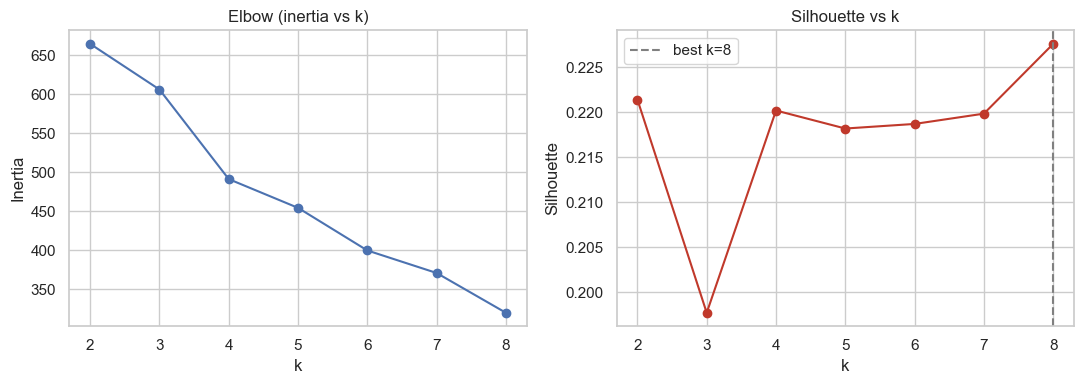

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow (inertia vs k)")
axes[1].plot(list(ks), sil_scores, marker="o", color="#c0392b")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].set_title("Silhouette vs k")
axes[1].axvline(best_k, color="gray", ls="--", label=f"best k={best_k}")
axes[1].legend()
plt.tight_layout()
plt.show()

**Insight:**

The elbow and silhouette plots provide complementary perspectives on the appropriate number of clusters.

From the **elbow plot**, inertia decreases steadily as K increases, with a noticeable reduction in slope after **K ≈ 4–5**. This suggests that adding more clusters beyond this point yields **diminishing returns in reducing within-cluster variance**, indicating a potential elbow in this region.

From the **silhouette plot**, the highest score occurs at **K = 8**, but the differences across values of K (particularly between K = 4 and K = 8) are relatively small. This indicates that while K = 8 produces the best separation according to the metric, the overall clustering structure is **moderately defined rather than strongly distinct**.

Taken together, these results suggest that:
- Smaller values of K (around 4–5) provide a good balance between simplicity and cluster compactness  
- Larger values of K (such as 8) improve separation slightly but may reduce interpretability  

In practice, the final choice of K should consider both the statistical evidence and the interpretability of the resulting clusters. In this analysis, **K = 8 is selected** to capture more granular differences between airport delay profiles, while acknowledging that the improvement over smaller K values is incremental rather than dramatic.

---

## Step 5: Fit K-Means Model with Selected Number of Clusters

Using the selected value of **K = 8**, the K-Means clustering algorithm is applied to the standardized airport feature set. Each airport is assigned to one of the clusters based on similarity in its delay profile.

The model partitions the airports into groups such that those within the same cluster have similar characteristics in terms of **delay frequency, delay severity, and delay composition**.

In [8]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
airports_model["cluster"] = kmeans.fit_predict(X_scaled)
airports_model["cluster"].value_counts().sort_index()

cluster
0     8
1    19
2     6
3     5
4     8
5     7
6    16
7     3
Name: count, dtype: int64

---

## Step 6: Cluster Interpretation

In this step, the resulting clusters are interpreted using their **centroid values**, **dominant delay causes**, and **representative airports**.

The centroid of each cluster provides the average feature values for that group, allowing us to characterize clusters in terms of:
- **Delay frequency** (DelayedFlightRate)  
- **Delay severity** (AvgArrDelay)  
- **Contribution of different delay causes**  

Additionally, the dominant delay type is identified based on the largest proportional share, and a small set of representative airports is listed for each cluster to provide real-world context.

This enables each cluster to be interpreted as a distinct **airport delay profile**.

The table below summarizes each cluster, including its size, dominant delay cause, representative airports, and centroid feature values.

In [10]:
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
cent_df = pd.DataFrame(centroids_orig, columns=FEATURE_COLS)
cent_df.insert(0, "cluster", range(best_k))

share_cols = [
    "CarrierShare",
    "WeatherShare",
    "NASShare",
    "SecurityShare",
    "LateAircraftShare",
]
dominant = (
    cent_df[share_cols]
    .idxmax(axis=1)
    .str.replace("Share", "", regex=False)
    .str.strip()
)

rows = []
for c in range(best_k):
    sub = airports_model[airports_model["cluster"] == c]
    samples = sub.nlargest(5, "FlightsCount")["Origin"].tolist()
    rows.append({
        "cluster": c,
        "n_airports": len(sub),
        "dominant_delay_type": dominant.iloc[c],
        "sample_airports": ", ".join(samples),
    })

cluster_summary = pd.DataFrame(rows).merge(
    cent_df.add_prefix("centroid_").rename(columns={"centroid_cluster": "cluster"}),
    on="cluster",
    how="left",
)
cluster_summary



,cluster,n_airports,dominant_delay_type,sample_airports,centroid_DelayedFlightRate,centroid_AvgArrDelay,centroid_AvgCarrierDelay,centroid_AvgWeatherDelay,centroid_AvgNASDelay,centroid_AvgSecurityDelay,centroid_AvgLateAircraftDelay,centroid_CarrierShare,centroid_WeatherShare,centroid_NASShare,centroid_SecurityShare,centroid_LateAircraftShare
0,0,8,LateAircraft,"ORD, CLT, EWR, BOS, PHL",0.450767,7.834052,2.392066,0.443569,2.567262,0.018487,3.035499,0.281190,0.050752,0.304317,0.002218,0.361523
1,1,19,LateAircraft,"LGA, MCO, DCA, PIT, TPA",0.422885,5.581269,1.502956,0.273628,2.038157,0.003725,2.363810,0.242902,0.044338,0.330333,0.000591,0.381835
2,2,6,LateAircraft,"LAX, PHX, OAK, PDX, SJC",0.434101,4.529149,1.327493,0.072225,0.885561,0.018532,1.960861,0.304583,0.017066,0.206350,0.004368,0.467633
3,3,5,Carrier,"SLC, SEA, MEM, HNL, ANC",0.427848,3.912914,1.878544,0.148812,1.021759,0.005082,1.429785,0.426569,0.031608,0.220787,0.001107,0.319930
4,4,8,LateAircraft,"DEN, SFO, LAS, BWI, MDW",0.441564,6.657765,2.060999,0.238035,1.285931,0.011044,3.185767,0.304367,0.034744,0.187558,0.001676,0.471655
5,5,7,Carrier,"ATL, DFW, IAH, DTW, MSP",0.458308,6.880821,2.278430,0.498769,1.841695,0.007100,1.832016,0.353355,0.077398,0.288275,0.001095,0.279877
6,6,16,LateAircraft,"STL, SAN, BNA, MCI, MSY",0.413232,4.660166,1.124209,0.165851,1.178540,0.005905,2.246928,0.238957,0.034991,0.248573,0.001250,0.476230
7,7,3,LateAircraft,"BDL, PBI, PVD",0.414415,4.831356,1.196375,0.201720,2.192245,0.019267,2.298220,0.205225,0.036067,0.370719,0.003250,0.384740


**Insight:**

The clustering results reveal several distinct types of airport delay profiles:

- The majority of clusters are dominated by **Late Aircraft Delay**, indicating that **delay propagation is the most widespread issue across airports**. These clusters represent airports where delays are primarily inherited from earlier flights rather than originating locally.

- A smaller number of clusters (e.g., clusters 3 and 5) are dominated by **Carrier Delay**, suggesting that delays in these groups are more closely related to **airline-specific operational factors**, such as scheduling inefficiencies or ground handling.

- There is clear variation in both **delay severity and delay frequency** across clusters:
  - Some clusters exhibit **higher average arrival delays (e.g., clusters 0 and 5)**, indicating more severe disruptions.
  - Others have **lower average delays but similar delay rates**, suggesting more moderate but frequent delays.

- Cluster sizes are uneven:
  - Larger clusters represent **common operational patterns shared by many airports**
  - Smaller clusters capture **more specialized or extreme behaviors**, often associated with specific airport characteristics or network positions

- The sample airports provide meaningful context:
  - Major hubs such as **ATL, ORD, DEN, and DFW** appear in clusters with higher delay intensity, reflecting their role in handling large volumes of traffic and contributing to delay propagation
  - Smaller or regional airports appear in clusters with more moderate delay characteristics

Overall, the results suggest that airport delay behavior can be grouped into a set of **recurring operational profiles**, primarily driven by:
- **Delay propagation (Late Aircraft)**
- **Airline operations (Carrier Delay)**
- **Network congestion effects**

This confirms that delays are not random but follow structured patterns across the airport network.

---

## Step 7: PCA Projection for Two-Dimensional Visualization

Because the clustering model is fitted using a high-dimensional feature space, it is difficult to visualize the resulting airport groups directly. To address this, **Principal Component Analysis (PCA)** is used to project the standardized feature set onto two dimensions.

PCA does not create the clusters; rather, it provides a lower-dimensional representation that makes it easier to inspect how the airports are distributed and whether the clusters identified by K-Means appear reasonably separated in two-dimensional space.

The first two principal components capture the largest possible share of variation in the standardized features, allowing the main structure of the data to be visualized.

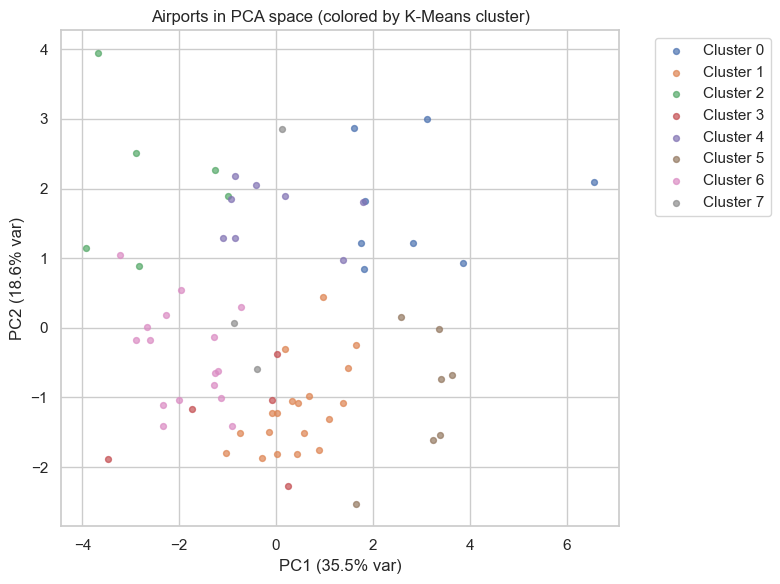

In [10]:
pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(X_scaled)
airports_model["pc1"] = xy[:, 0]
airports_model["pc2"] = xy[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(best_k):
    sub = airports_model[airports_model["cluster"] == c]
    ax.scatter(sub["pc1"], sub["pc2"], s=18, alpha=0.7, label=f"Cluster {c}")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Airports in PCA space (colored by K-Means cluster)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Insight:**

The PCA plot provides a two-dimensional view of the airport feature space, with points colored by their assigned K-Means cluster.

Several useful patterns can be observed:

- Some clusters appear relatively compact, indicating groups of airports with similar delay profiles.
- Other clusters overlap in the PCA space, suggesting that the differences between certain airport groups are more subtle.
- This overlap does **not necessarily mean the clustering is poor**, since PCA reduces the full feature space to only two dimensions and may not preserve all of the separation present in the original data.

Overall, the visualization suggests that the airport clusters are **partially distinguishable**, with some clear grouping alongside moderate overlap. This is consistent with the earlier silhouette results, which indicated that clustering structure exists but is not extremely strong.

Thus, the PCA projection supports the conclusion that airports exhibit meaningful delay-profile groupings, while also showing that these groupings are not perfectly separated in low-dimensional space.

---

## Visual Comparison of Cluster Profiles

This section visualizes the **cluster centroids** and **cluster sizes** to better understand how the airport groups differ.

The centroid plot shows the average feature values for each cluster in the original scale, allowing direct comparison of delay characteristics across clusters. This helps identify which clusters exhibit higher delay rates, greater delay severity, or stronger contributions from specific delay causes.

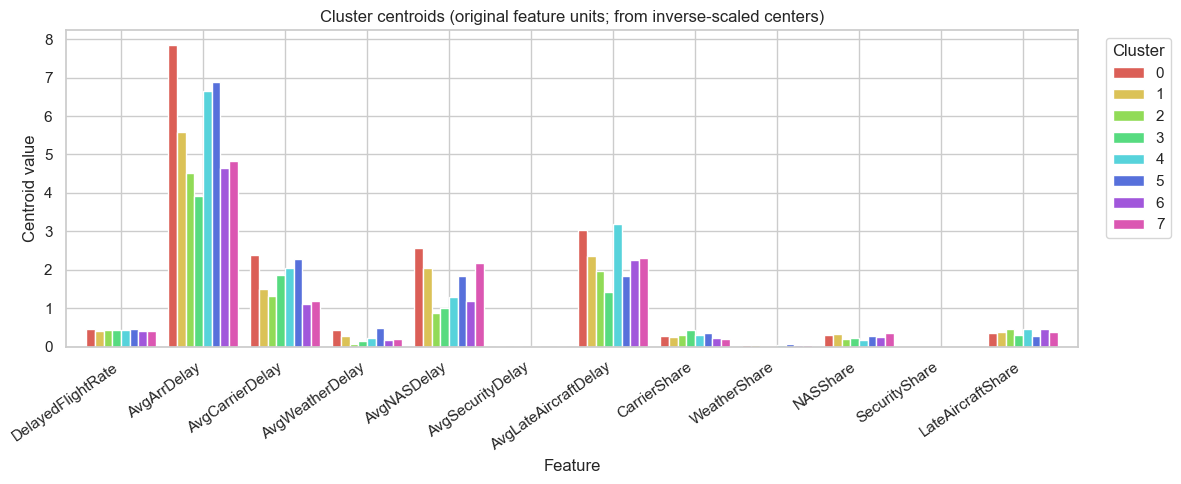

In [13]:
plot_cent = cent_df.set_index("cluster")[FEATURE_COLS]
fig, ax = plt.subplots(figsize=(12, 5))

colors = sns.color_palette("tab10", n_colors=best_k)

plot_cent.T.plot(
    kind="bar",
    ax=ax,
    width=0.85,
    color=sns.color_palette("hls", 8)
)

ax.set_title("Cluster centroids (original feature units; from inverse-scaled centers)")
ax.set_xlabel("Feature")
ax.set_ylabel("Centroid value")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

**Insight:**

The centroid comparison highlights clear differences between clusters in terms of delay behavior:

- Some clusters exhibit **higher average arrival delays and higher delay rates**, indicating more severe and frequent disruptions.
- Others show **lower delay levels**, representing relatively more efficient or less congested airports.
- Differences across **cause-specific features** (e.g., Carrier, NAS, Late Aircraft) reveal that clusters are not only separated by magnitude of delay, but also by the **structure of delay causes**.

In particular:
- Clusters with higher **Late Aircraft Delay** reflect strong delay propagation effects.
- Clusters with higher **Carrier Delay** suggest operational inefficiencies specific to airlines.
- Variation in NAS-related features indicates differing levels of exposure to congestion.

Overall, the centroid plot confirms that the clustering successfully separates airports into groups with **distinct operational delay profiles**, supporting the earlier interpretation of cluster structure.

---

### Cluster Sizes

The bar chart below shows the number of airports assigned to each cluster. This provides an overview of how the clustering model partitions the dataset and whether clusters are balanced or dominated by a few large groups.

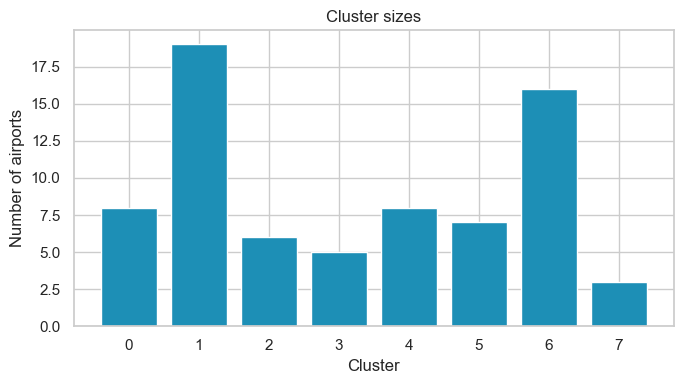

In [14]:
vc = airports_model["cluster"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(vc.index.astype(str), vc.values, color="#1d8fb6")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of airports")
ax.set_title("Cluster sizes")
plt.tight_layout()
plt.show()

**Insight:**

The cluster size distribution shows that the clusters are not evenly balanced:

- Some clusters (e.g., clusters 1 and 6) contain a **larger number of airports**, indicating common delay patterns shared across many locations.
- Other clusters (e.g., cluster 7) are relatively **small**, representing more specialized or unique airport behaviors.

This imbalance is expected in real-world systems, where a few dominant operational patterns occur frequently, while a smaller number of airports exhibit distinct or extreme delay characteristics.

Overall, the results suggest that most airports fall into a set of **common delay profiles**, with a smaller subset forming more specialized groups that may require targeted operational attention.

---

### Representative Airports by Cluster

To provide additional context for each cluster, the table below lists the **top airports (by flight volume)** within each cluster.

These representative airports help ground the clustering results in real-world examples, making it easier to understand the types of airports that belong to each group.

In [16]:
rep_rows = []
for c in range(best_k):
    sub = airports_model[airports_model["cluster"] == c].nlargest(10, "FlightsCount")
    for _, r in sub.iterrows():
        rep_rows.append({"cluster": c, "Origin": r["Origin"], "FlightsCount": r["FlightsCount"]})
representative_airports = pd.DataFrame(rep_rows)
representative_airports

,cluster,Origin,FlightsCount
0,0,ORD,100208
1,0,CLT,42452
2,0,EWR,40510
3,0,BOS,36341
4,0,PHL,31712
5,0,JFK,25631
6,0,IAD,20400
7,0,FLL,18934
8,1,LGA,35590
9,1,MCO,34145


**Insight:**

The representative airports further clarify the characteristics of each cluster:

- High-traffic hubs such as **ORD, JFK, BOS, and EWR** appear prominently, indicating that major airports play a key role in shaping cluster profiles.
- These airports are typically associated with **higher delay intensity and stronger delay propagation effects**, consistent with earlier centroid analysis.
- Other clusters include mid-sized airports such as **MCO, DCA, and PIT**, suggesting more moderate but still structured delay behavior.

By examining these representative airports, it becomes clear that clusters are not abstract groupings but correspond to **real operational categories**, often reflecting airport size, connectivity, and position within the flight network.

This reinforces the validity of the clustering approach and provides a practical interpretation of the results.

## Export of Clustering Results

The final step exports the key outputs of the clustering analysis to CSV files for further use in reporting, visualization, or external analysis.

The following datasets are generated:
- **airport_delay_profiles.csv**: full airport-level feature set with cluster assignments and PCA coordinates  
- **airport_clusters.csv**: simplified dataset containing key variables and cluster labels  
- **cluster_summary.csv**: summary of cluster characteristics, including centroid values, dominant delay causes, and representative airports  

These outputs provide a reusable summary of the clustering results and support interpretation outside of the notebook environment.

In [14]:
profiles_out = profiles.merge(
    airports_model[["Origin", "cluster", "pc1", "pc2"]],
    on="Origin",
    how="left",
)
profiles_out.to_csv("airport_delay_profiles.csv", index=False)

airport_clusters = airports_model[[
    "Origin",
    "FlightsCount",
    "DelayedFlightRate",
    "AvgArrDelay",
    "cluster",
    "pc1",
    "pc2",
]].copy()
airport_clusters.to_csv("airport_clusters.csv", index=False)

cluster_summary.to_csv("cluster_summary.csv", index=False)